# Examples of mapping real-world fixed-route buses into the simulation

This notebook loads the current client and launch utilities from the gitignored `METS-R_HPC/` asset. API responses use the native v2 schema: `messageType`, `status`, lowercase `data`, and camelCase fields.

In [15]:
from pathlib import Path
import os
import shutil
import sys

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "METS-R_HPC":
    PROJECT_ROOT = PROJECT_ROOT.parent
METS_R_HPC_DIR = PROJECT_ROOT / "METS-R_HPC"
if not (METS_R_HPC_DIR / "clients" / "METSRClient.py").is_file():
    raise FileNotFoundError("Clone https://github.com/umnilab/METS-R_HPC.git into ./METS-R_HPC first")
shutil.copytree(PROJECT_ROOT / "data", METS_R_HPC_DIR / "data", dirs_exist_ok=True)

if str(METS_R_HPC_DIR) not in sys.path:
    sys.path.insert(0, str(METS_R_HPC_DIR))

from utils.util import *
from clients.METSRClient import METSRClient

# Example 1: Run the transit route in the simulation (open loop)

In [16]:
with open("input/Birmingham_transit_data/stop_to_link_mapping.json", "r") as f:
      stop2link = json.load(f)

for i in range(1):
      print(stop2link[list(stop2link.keys())[i]])

{'stops': [[-86.874491, 33.49398], [-86.859491, 33.500061], [-86.845215, 33.499688], [-86.841138, 33.498493], [-86.839618, 33.493104], [-86.834799, 33.490707], [-86.827743, 33.494075], [-86.820784, 33.497392], [-86.810902, 33.503497], [-86.806807, 33.505514], [-86.804913, 33.507946], [-86.806948, 33.510819], [-86.808124, 33.5127], [-86.786178, 33.52359], [-86.776278, 33.528352], [-86.771852, 33.530353], [-86.760746, 33.535633], [-86.750615, 33.541226]], 'stop_zones': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18], 'assigned_links': ['-183945766#2', '7766854#18', '870847372#0', '183945767#4', '7745224', '-7749206#9', '-608662037#14', '-608662037#1', '-422477569', '746300584#9', '771558766#6', '-751530242#7', '259309286#1', '165419545#0', '-165419545#17', '165419545#23', '-736505309#3', '-7737602#2'], 'route_links': ['203055723#4', '7778958#1', '203055723#4', '-7737602#2', '-7737602#1', '7737602#2', '-7737602#2', '203055723#4', '-7778958#1', '203055723#2', '203055723#1',

In [17]:
config = read_run_config(str(PROJECT_ROOT / "configs" / "run_interactive_Birmingham.json"))
config.zone_file = "data/Birmingham/facility/zone/bus_zones"
config.charging_station_file = "data/Birmingham/facility/charging_station/birmingham_cs"

In [18]:
notebook_cwd = Path.cwd()
try:
    os.chdir(METS_R_HPC_DIR)
    sim_dirs = prepare_sim_dirs(config)
    run_simulation_in_docker(config)
    sim_dirs = [str(Path(sim_dir).resolve()) for sim_dir in sim_dirs]
    config.sim_dirs = sim_dirs
finally:
    os.chdir(notebook_cwd)

print(sim_dirs)


No port number specified, find available ports for simulation instances
['C:\\Users\\ALei\\git\\coE3T\\METS-R_HPC\\output\\Birmingham_20260816_023529_seed_42']


In [19]:
sim_client = METSRClient(
    host=config.metsr_host,
    port=config.ports[0],
    sim_folder=sim_dirs[0],
    config=config,
    verbose=False,
    timeout=300,
)

Connection established!


In [20]:
# add the first bus route to the simulation
for route_name, route_info in stop2link.items():
    print(f"Route Name: {route_name}")
    sim_client.add_bus_route(routeName=route_name, zone = route_info["stop_zones"], road= route_info["assigned_links"])
    break

Route Name: 100_36_1


In [21]:
route_info = sim_client.query_bus_route("100_36_1")
route_info

{'data': [{'stopZoneIds': [1,
    2,
    3,
    4,
    5,
    6,
    7,
    8,
    9,
    10,
    11,
    12,
    13,
    14,
    15,
    16,
    17,
    18],
   'routeId': 0,
   'stopRoadIds': ['-183945766#2',
    '7766854#18',
    '870847372#0',
    '183945767#4',
    '7745224',
    '-7749206#9',
    '-608662037#14',
    '-608662037#1',
    '-422477569',
    '746300584#9',
    '771558766#6',
    '-751530242#7',
    '259309286#1',
    '165419545#0',
    '-165419545#17',
    '165419545#23',
    '-736505309#3',
    '-7737602#2'],
   'routeName': '100_36_1'}],
 'messageType': 'busRoute',
 'status': 'ok'}

In [22]:
# add a bus run to the first route
for route_name, route_info in stop2link.items():
    print(f"Route Name: {route_name}")
    print(sim_client.add_bus_run(routeName = route_name, departTime = [0] * len(route_info['stop_zones'])))
    break

Route Name: 100_36_1
{'data': [{'routeName': '100_36_1', 'status': 'ok'}], 'messageType': 'addBusRun', 'status': 'ok'}


In [23]:
sim_client.tick(600)

In [24]:
bus_info = sim_client.query_route_bus(route_name)
while not bus_info["data"][0]["busIds"]:
      sim_client.tick(120)
      bus_info = sim_client.query_route_bus(route_name)

bus_ids = bus_info["data"][0]["busIds"]
bus_id = bus_ids[0]
bus_info

{'data': [{'routeId': 0, 'busIds': [1000], 'routeName': '100_36_1'}],
 'messageType': 'busWithRoute',
 'status': 'ok'}

In [25]:
sim_client.query_bus(bus_id)

{'data': [{'stopZoneIds': [1,
    2,
    3,
    4,
    5,
    6,
    7,
    8,
    9,
    10,
    11,
    12,
    13,
    14,
    15,
    16,
    17,
    18],
   'onRoad': True,
   'connectorDistance': 0.2907669314396932,
   'destX': -86.85833606214621,
   'matchedRequests': 0,
   'destY': 33.50021963728471,
   'distanceToSegmentEnd': 0.29080465319559323,
   'targetRoadId': '183945766#6',
   'onConnector': True,
   'battery': 243.64363116795283,
   'speed': 0.0,
   'transitionPending': False,
   'routeName': '100_36_1',
   'pickupPassengers': 0,
   'routeId': 0,
   'segmentId': '183945766#5_183945766#6',
   'dropoffRequests': 0,
   'destinationRoadId': '7766854#18',
   'prevY': 33.49276823748905,
   'prevX': -86.8723651547583,
   'pickupRequests': 0,
   'intersectionCollision': False,
   'busId': 1000,
   'matchedPassengers': 0,
   'controlMode': 'native',
   'currentParkingRoadId': None,
   'connectorTravelTimeRemaining': 0.013085820496835878,
   'stopZoneCount': 18,
   'currentStopIn

In [26]:
# collect the vehicle path
xs, ys = [], []

# Run a 60 min simulation, record the trajectory every 1s
for i in range(3600):
      query_res = sim_client.query_vehicle(bus_id)
      xs.append(query_res["data"][0]["x"])
      ys.append(query_res["data"][0]["y"])

      sim_client.tick(5)

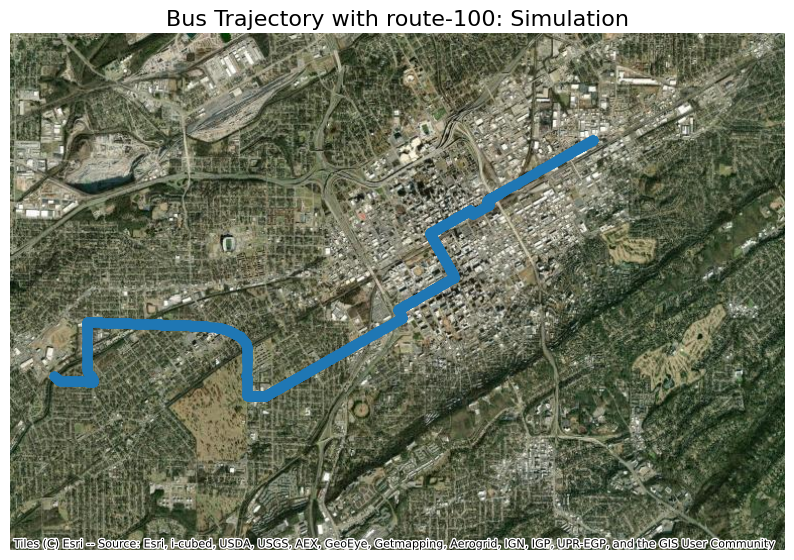

In [27]:
import matplotlib.pyplot as plt
import contextily as ctx
import geopandas as gpd

# Force the default size for all figures in this script
plt.rcParams['figure.figsize'] = (10, 10)
# plt.rcParams['figure.dpi']     = 100

# Example 1: Collect and visualize the trajectory of one vehicle
fig, ax = plt.subplots()  
# (Because of rcParams above, this will be 10"×10" at 100 dpi.)

gdf = (
    gpd.GeoDataFrame(
        geometry=gpd.points_from_xy(xs, ys),
        crs='EPSG:4326'
    )
    .to_crs(epsg=3857)
)
gdf.plot(ax=ax)
ax.set_title("Bus Trajectory with route-100: Simulation", fontsize= 16)

# Add the basemap without changing fig size
ctx.add_basemap(ax, source=ctx.providers.Esri.WorldImagery, reset_extent=False)

ax.set_axis_off()

# If you save, this guarantees the output file is also 10"x10"
# fig.savefig("trajectory.png", bbox_inches='tight')
plt.show()


In [28]:
sim_client.terminate()

# Example 2: Bus run to simulation mapping (closed loop)

Closed-loop replay keeps the mapped bus responsive to surrounding simulated traffic while its observed position is updated from the trace.

In [29]:
from pathlib import Path
import os
import shutil
import sys

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "METS-R_HPC":
    PROJECT_ROOT = PROJECT_ROOT.parent
METS_R_HPC_DIR = PROJECT_ROOT / "METS-R_HPC"
if not (METS_R_HPC_DIR / "clients" / "METSRClient.py").is_file():
    raise FileNotFoundError("Clone https://github.com/umnilab/METS-R_HPC.git into ./METS-R_HPC first")
shutil.copytree(PROJECT_ROOT / "data", METS_R_HPC_DIR / "data", dirs_exist_ok=True)

if str(METS_R_HPC_DIR) not in sys.path:
    sys.path.insert(0, str(METS_R_HPC_DIR))

from utils.util import *
from clients.METSRClient import METSRClient

In [30]:
config = read_run_config(str(PROJECT_ROOT / "configs" / "run_interactive_Birmingham.json"))
config.zone_file = "data/Birmingham/facility/zone/bus_zones"
config.charging_station_file = "data/Birmingham/facility/charging_station/birmingham_cs"

In [31]:
with open("input/Birmingham_transit_data/final_bus_runs_dictionary.json", "r") as f:
      busrun2trajectory = json.load(f)

for i in range(1):
      print(busrun2trajectory[list(busrun2trajectory.keys())[i]])

{'route_variant': '1_2_1', 'visited_stop': [321, 322, 323, 324, 325, 326, 327, 329, 330, 331, 332, 333, 334, 335, 336, 337, 338, 339, 341, 344, 345, 349, 355, 356, 357, 360, 363, 364, 365, 370, 371, 374, 376, 377, 378, 379, 380], 'visited_road': ['-39992256', '769551523#10', '7765425#8', '119882420#6', '260003377', '259324658#5', '259324658#7', '260003379#3', '846366626#15', '846366626#15', '259323201#0', '259323201#2', '259323201#5', '259323201#11', '259323201#19', '259323201#20', '7759916#0', '7759916#2', '7759916#7', '7759916#25', '7759916#25', '7759916#43', '-313631565#19', '-313631565#13', '-313631565#6', '-313631567#5', '-774607064#6', '870847367#1', '-870847369#3', '-7783711#5', '183944547#5', '-7779373#5', '48688394#9', '-138812693#8', '1175015162#1', '872881113#1', '259308438#2'], 'path': [{'from_stop_index': 0, 'to_stop_index': 1, 'path_details': [{'linkID': '-39992256', 'distance': 74.790241342072, 'offset': 0.0}, {'linkID': '-39992256', 'distance': 0, 'offset': 22.568948}, 

In [32]:
notebook_cwd = Path.cwd()
try:
    os.chdir(METS_R_HPC_DIR)
    sim_dirs = prepare_sim_dirs(config)
    run_simulation_in_docker(config)
    sim_dirs = [str(Path(sim_dir).resolve()) for sim_dir in sim_dirs]
    config.sim_dirs = sim_dirs
finally:
    os.chdir(notebook_cwd)

print(sim_dirs)

No port number specified, find available ports for simulation instances
['C:\\Users\\ALei\\git\\coE3T\\METS-R_HPC\\output\\Birmingham_20260816_023634_seed_42']


In [33]:
sim_client = METSRClient(
    host=config.metsr_host,
    port=config.ports[0],
    sim_folder=sim_dirs[0],
    config=config,
    verbose=False,
    timeout=300,
)

Connection established!


In [34]:
def format_path(raw_path):
      paths = []
      for segment in raw_path:
            current_link = None
            path = []
            for link in segment['path_details']:
                  if link['linkID'] != current_link:
                        current_link = link['linkID']
                        path.append(current_link)
            paths.append(path)
      return paths

def process_path(raw_path, offset):
      # find the segment that the vehicle is within
      start_node = None
      end_node = None
      for path in raw_path:
            for segment in path['path_details']:
                  if offset < segment['offset']:
                        end_node = segment
                        break
                  else:
                        start_node = segment
                  
            if end_node is not None:
                  break
      linkID = end_node['linkID']
      distance = - (start_node['distance'] - end_node['distance']) * (offset - start_node['offset']) / (end_node['offset'] - start_node['offset']) + start_node['distance']

      return linkID, distance

In [35]:
for bus_run_name, compressed_trajectory in busrun2trajectory.items():
    print(f"Bus Run Name: {bus_run_name}")
    route_name = compressed_trajectory['route_variant']
    print(f"Route Name: {route_name}")

    zone_list = compressed_trajectory['visited_stop']
    road_list = compressed_trajectory['visited_road']
    path_list = compressed_trajectory['path']

    print(sim_client.add_bus_route(route_name, zone_list, road_list, format_path(path_list)))
    break

Bus Run Name: 1_101_312
Route Name: 1_2_1
{'data': [{'routeName': '1_2_1', 'status': 'ok'}], 'messageType': 'addBusRouteWithPath', 'status': 'ok'}


In [36]:
# add a bus run to the first route
for bus_run_name, compressed_trajectory in busrun2trajectory.items():
    print(f"Route Name: {compressed_trajectory['route_variant']}")
    print(sim_client.add_bus_run(routeName = [compressed_trajectory['route_variant'],compressed_trajectory['route_variant']], departTime = [[0] * len(zone_list), [0] * len(zone_list)]))
    break

Route Name: 1_2_1
{'data': [{'routeName': '1_2_1', 'status': 'ok'}, {'routeName': '1_2_1', 'status': 'ok'}], 'messageType': 'addBusRun', 'status': 'ok'}


In [37]:
bus_info = sim_client.query_route_bus(route_name)

# wait until a bus is assigned to the route (depending on whether there is a bus at the beginning of the stop)
while not bus_info["data"][0]["busIds"]:
      sim_client.tick(120)
      bus_info = sim_client.query_route_bus(route_name)

replay_bus_id = bus_info["data"][0]["busIds"][0]

In [38]:
bus_info

{'data': [{'routeId': 0, 'busIds': [1028, 1029], 'routeName': '1_2_1'}],
 'messageType': 'busWithRoute',
 'status': 'ok'}

In [39]:
sim_client.query_vehicle(replay_bus_id)

{'data': [{'onRoad': True,
   'connectorDistance': 8.053782347351175,
   'destX': -86.97703579097717,
   'destY': 33.389309560773185,
   'distanceToSegmentEnd': 8.009219429330699,
   'targetRoadId': '1216376805#0',
   'onConnector': True,
   'battery': 243.76661521430464,
   'speed': 0.24000000357627868,
   'transitionPending': False,
   'acceleration': 1.2,
   'segmentId': '39992256_1216376805#0',
   'destinationRoadId': '769551523#10',
   'vehicleClass': 2,
   'prevY': 33.3764949821564,
   'totalEnergyConsumed': 0.11592691802513198,
   'prevX': -87.00986689928084,
   'vehicleId': 1028,
   'state': 3,
   'intersectionCollision': False,
   'tripNumber': 3,
   'originZoneId': 321,
   'controlMode': 'native',
   'currentParkingRoadId': None,
   'connectorTravelTimeRemaining': 0.5117712095418977,
   'bearing': -0.07678028384474393,
   'originX': -87.00988606678544,
   'originY': 33.375820793260544,
   'originRoadId': '39992256',
   'laneIndex': None,
   'destinationZoneId': 322,
   'conne

In [40]:
# collect the vehicle path
xs, ys = [], []

current_ind = 0
# Run a 60 min simulation, record the trajectory every 1s
for i in range(3600):
      link, distance = process_path(path_list, i)

      sim_client.teleport_digital_twin_vehicle(replay_bus_id, link, 0, distance)
      
      query_res = sim_client.query_vehicle(replay_bus_id)
      
      xs.append(query_res["data"][0]["x"])
      ys.append(query_res["data"][0]["y"])

      sim_client.tick(5)

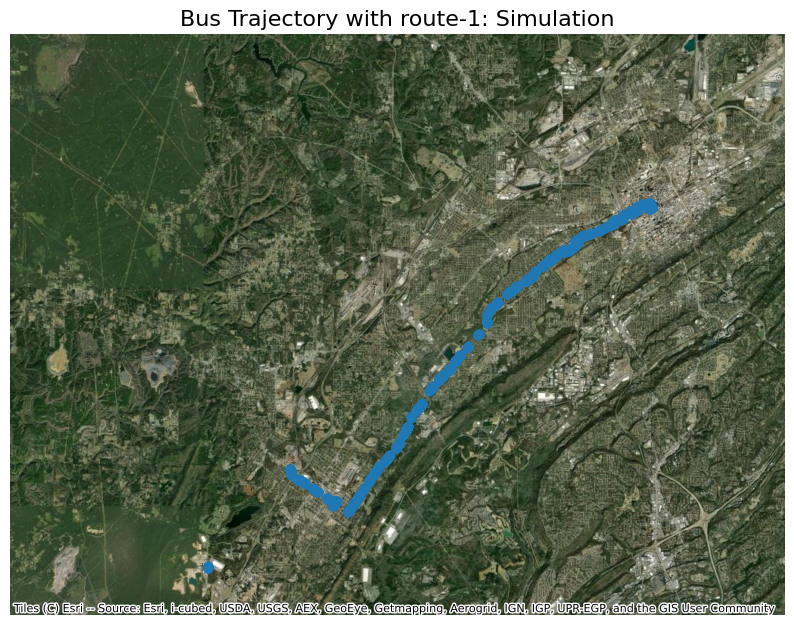

In [41]:
import matplotlib.pyplot as plt
import contextily as ctx
import geopandas as gpd

# Force the default size for all figures in this script
plt.rcParams['figure.figsize'] = (10, 10)
# plt.rcParams['figure.dpi']     = 100

# Example 1: Collect and visualize the trajectory of one vehicle
fig, ax = plt.subplots()  
# (Because of rcParams above, this will be 10"×10" at 100 dpi.)

# add the NYC map
gdf = (
    gpd.GeoDataFrame(
        geometry=gpd.points_from_xy(xs, ys),
        crs='EPSG:4326'
    )
    .to_crs(epsg=3857)
)
gdf.plot(ax=ax)
ax.set_title("Bus Trajectory with route-1: Simulation", fontsize= 16)

# Add the basemap without changing fig size
ctx.add_basemap(ax, source=ctx.providers.Esri.WorldImagery, reset_extent=False)

ax.set_axis_off()

# If you save, this guarantees the output file is also 10"x10"
# fig.savefig("trajectory2.png", bbox_inches='tight')
plt.show()


Although the original GPS data contain gaps of approximately 30 seconds that result in missing link associations, this mechanism nevertheless ensures that the observed links provide an accurate mapping of the vehicles’ true positions. To achieve more complete trajectory reconstruction, we need to infer the intermediate links that bridge these observation intervals.

In [42]:
sim_client.terminate()

# Example 3: Change the route on the go

In [43]:
from pathlib import Path
import os
import shutil
import sys

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "METS-R_HPC":
    PROJECT_ROOT = PROJECT_ROOT.parent
METS_R_HPC_DIR = PROJECT_ROOT / "METS-R_HPC"
if not (METS_R_HPC_DIR / "clients" / "METSRClient.py").is_file():
    raise FileNotFoundError("Clone https://github.com/umnilab/METS-R_HPC.git into ./METS-R_HPC first")
shutil.copytree(PROJECT_ROOT / "data", METS_R_HPC_DIR / "data", dirs_exist_ok=True)

if str(METS_R_HPC_DIR) not in sys.path:
    sys.path.insert(0, str(METS_R_HPC_DIR))

from utils.util import *
from clients.METSRClient import METSRClient

In [44]:
with open("input/Birmingham_transit_data/stop_to_link_mapping.json", "r") as f:
      stop2link = json.load(f)

for i in range(2):
      print(stop2link[list(stop2link.keys())[i]])

{'stops': [[-86.874491, 33.49398], [-86.859491, 33.500061], [-86.845215, 33.499688], [-86.841138, 33.498493], [-86.839618, 33.493104], [-86.834799, 33.490707], [-86.827743, 33.494075], [-86.820784, 33.497392], [-86.810902, 33.503497], [-86.806807, 33.505514], [-86.804913, 33.507946], [-86.806948, 33.510819], [-86.808124, 33.5127], [-86.786178, 33.52359], [-86.776278, 33.528352], [-86.771852, 33.530353], [-86.760746, 33.535633], [-86.750615, 33.541226]], 'stop_zones': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18], 'assigned_links': ['-183945766#2', '7766854#18', '870847372#0', '183945767#4', '7745224', '-7749206#9', '-608662037#14', '-608662037#1', '-422477569', '746300584#9', '771558766#6', '-751530242#7', '259309286#1', '165419545#0', '-165419545#17', '165419545#23', '-736505309#3', '-7737602#2'], 'route_links': ['203055723#4', '7778958#1', '203055723#4', '-7737602#2', '-7737602#1', '7737602#2', '-7737602#2', '203055723#4', '-7778958#1', '203055723#2', '203055723#1',

In [45]:
config = read_run_config(str(PROJECT_ROOT / "configs" / "run_interactive_Birmingham.json"))
config.zone_file = "data/Birmingham/facility/zone/bus_zones"
config.charging_station_file = "data/Birmingham/facility/charging_station/birmingham_cs"

In [46]:
notebook_cwd = Path.cwd()
try:
    os.chdir(METS_R_HPC_DIR)
    sim_dirs = prepare_sim_dirs(config)
    run_simulation_in_docker(config)
    sim_dirs = [str(Path(sim_dir).resolve()) for sim_dir in sim_dirs]
    config.sim_dirs = sim_dirs
finally:
    os.chdir(notebook_cwd)

print(sim_dirs)

No port number specified, find available ports for simulation instances
['C:\\Users\\ALei\\git\\coE3T\\METS-R_HPC\\output\\Birmingham_20260816_023735_seed_42']


In [47]:
sim_client = METSRClient(
    host=config.metsr_host,
    port=config.ports[0],
    sim_folder=sim_dirs[0],
    config=config,
    verbose=False,
    timeout=300,
)

Connection established!


In [48]:
# add the first bus route to the simulation
for route_name, route_info in stop2link.items():
    print(f"Route Name: {route_name}")
    sim_client.add_bus_route(routeName=route_name, zone = route_info["stop_zones"], road= route_info["assigned_links"])
    break

Route Name: 100_36_1


In [49]:
route_info = sim_client.query_bus_route("100_36_1")
route_info

{'data': [{'stopZoneIds': [1,
    2,
    3,
    4,
    5,
    6,
    7,
    8,
    9,
    10,
    11,
    12,
    13,
    14,
    15,
    16,
    17,
    18],
   'routeId': 0,
   'stopRoadIds': ['-183945766#2',
    '7766854#18',
    '870847372#0',
    '183945767#4',
    '7745224',
    '-7749206#9',
    '-608662037#14',
    '-608662037#1',
    '-422477569',
    '746300584#9',
    '771558766#6',
    '-751530242#7',
    '259309286#1',
    '165419545#0',
    '-165419545#17',
    '165419545#23',
    '-736505309#3',
    '-7737602#2'],
   'routeName': '100_36_1'}],
 'messageType': 'busRoute',
 'status': 'ok'}

In [50]:
# add a bus run to the first route
for route_name, route_info in stop2link.items():
    print(f"Route Name: {route_name}")
    print(sim_client.add_bus_run(routeName = [route_name, route_name], departTime = [[0] * len(route_info['stop_zones']), [0] * len(route_info['stop_zones'])]))
    break

Route Name: 100_36_1
{'data': [{'routeName': '100_36_1', 'status': 'ok'}, {'routeName': '100_36_1', 'status': 'ok'}], 'messageType': 'addBusRun', 'status': 'ok'}


In [51]:
sim_client.tick(600)

In [52]:
bus_info = sim_client.query_route_bus(route_name)
while len(bus_info["data"][0]["busIds"]) < 2:
      sim_client.tick(120)
      bus_info = sim_client.query_route_bus(route_name)

bus_ids = bus_info["data"][0]["busIds"][:2]
bus_info

{'data': [{'routeId': 0, 'busIds': [1000, 1001], 'routeName': '100_36_1'}],
 'messageType': 'busWithRoute',
 'status': 'ok'}

In [53]:
sim_client.query_bus(bus_ids)

{'data': [{'stopZoneIds': [1,
    2,
    3,
    4,
    5,
    6,
    7,
    8,
    9,
    10,
    11,
    12,
    13,
    14,
    15,
    16,
    17,
    18],
   'onRoad': True,
   'connectorDistance': 0.2907669314396932,
   'destX': -86.85833606214621,
   'matchedRequests': 0,
   'destY': 33.50021963728471,
   'distanceToSegmentEnd': 0.29080465319559323,
   'targetRoadId': '183945766#6',
   'onConnector': True,
   'battery': 243.64363116795283,
   'speed': 0.0,
   'transitionPending': False,
   'routeName': '100_36_1',
   'pickupPassengers': 0,
   'routeId': 0,
   'segmentId': '183945766#5_183945766#6',
   'dropoffRequests': 0,
   'destinationRoadId': '7766854#18',
   'prevY': 33.49276823748905,
   'prevX': -86.8723651547583,
   'pickupRequests': 0,
   'intersectionCollision': False,
   'busId': 1000,
   'matchedPassengers': 0,
   'controlMode': 'native',
   'currentParkingRoadId': None,
   'connectorTravelTimeRemaining': 0.013085820496835878,
   'stopZoneCount': 18,
   'currentStopIn

In [54]:
# for testing, remove all the intermediate stops
for i in range(16):
      print(sim_client.remove_bus_stop(busID=bus_ids[0], routeName=route_name, stopIndex=1))

{'data': [{'busId': 1000, 'status': 'ok'}], 'messageType': 'removeStopFromRoute', 'status': 'ok'}
{'data': [{'busId': 1000, 'status': 'ok'}], 'messageType': 'removeStopFromRoute', 'status': 'ok'}
{'data': [{'busId': 1000, 'status': 'ok'}], 'messageType': 'removeStopFromRoute', 'status': 'ok'}
{'data': [{'busId': 1000, 'status': 'ok'}], 'messageType': 'removeStopFromRoute', 'status': 'ok'}
{'data': [{'busId': 1000, 'status': 'ok'}], 'messageType': 'removeStopFromRoute', 'status': 'ok'}
{'data': [{'busId': 1000, 'status': 'ok'}], 'messageType': 'removeStopFromRoute', 'status': 'ok'}
{'data': [{'busId': 1000, 'status': 'ok'}], 'messageType': 'removeStopFromRoute', 'status': 'ok'}
{'data': [{'busId': 1000, 'status': 'ok'}], 'messageType': 'removeStopFromRoute', 'status': 'ok'}
{'data': [{'busId': 1000, 'status': 'ok'}], 'messageType': 'removeStopFromRoute', 'status': 'ok'}
{'data': [{'busId': 1000, 'status': 'ok'}], 'messageType': 'removeStopFromRoute', 'status': 'ok'}
{'data': [{'busId': 

In [55]:
sim_client.insert_bus_stop(busID=bus_ids[1], routeName=route_name, zoneID=20, roadName='-736505309#2', stopIndex=1)

{'data': [{'busId': 1001, 'status': 'ok'}],
 'messageType': 'insertStopToRoute',
 'status': 'ok'}

In [56]:
# collect the vehicle path
xs, ys = [], []
x2s, y2s = [], []

# Run a 60 min simulation, record the trajectory every 1s
for i in range(3600):
      query_res = sim_client.query_vehicle(bus_ids)
      xs.append(query_res["data"][0]["x"])
      ys.append(query_res["data"][0]["y"])

      x2s.append(query_res["data"][1]["x"])
      y2s.append(query_res["data"][1]["y"])


      sim_client.tick(5)

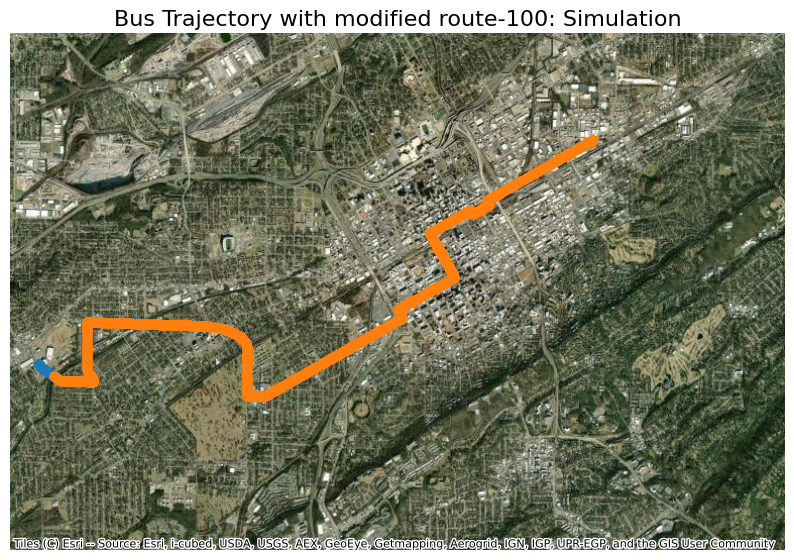

In [57]:
import matplotlib.pyplot as plt
import contextily as ctx
import geopandas as gpd

# Force the default size for all figures in this script
plt.rcParams['figure.figsize'] = (10, 10)
# plt.rcParams['figure.dpi']     = 100

# Example 1: Collect and visualize the trajectory of one vehicle
fig, ax = plt.subplots()  
# (Because of rcParams above, this will be 10"×10" at 100 dpi.)

gdf = (
    gpd.GeoDataFrame(
        geometry=gpd.points_from_xy(xs, ys),
        crs='EPSG:4326'
    )
    .to_crs(epsg=3857)
)
gdf.plot(ax=ax)

gdf2 = (
    gpd.GeoDataFrame(
        geometry=gpd.points_from_xy(x2s, y2s),
        crs='EPSG:4326'
    )
    .to_crs(epsg=3857)
)
gdf2.plot(ax=ax)

ax.set_title("Bus Trajectory with modified route-100: Simulation", fontsize= 16)

# Add the basemap without changing fig size
ctx.add_basemap(ax, source=ctx.providers.Esri.WorldImagery, reset_extent=False)

ax.set_axis_off()

# If you save, this guarantees the output file is also 10"x10"
# fig.savefig("trajectory.png", bbox_inches='tight')
plt.show()


In [58]:
sim_client.terminate()